TokaMaker Example: Equilibrium reconstruction for SPARC {#doc_tMaker_SPARC_ex2}
==========
This is based on the open source SPARC data published by Commonwealth Fusion Systems (CFS) in the [SPARCPublic](https://github.com/cfs-energy/SPARCPublic/) repository. We reconstruct the Primary Reference Discharge (PRD), the SPARC baseline H-mode scenario ($R_0 = 1.85$ m, $B_0 = 12.2$ T, $I_p = 8.7$ MA), described in Creely et al, "Overview of the SPARC tokamak", J. Plasma Phys. 86(5), 865860502 (2020). https://doi.org/10.1017/S0022377820001257

All files are openly available on GitHub at: https://github.com/cfs-energy/SPARCPublic/

This notebook uses the mesh built in \ref doc_tMaker_SPARC_ex1 (`SPARC_public_make_mesh.ipynb`) and takes its equilibrium parameters and profiles from the double-null FreeGS gEQDSK, `2 - SPARC_DN_PRD_freegs_20221013`, in the [PrimaryReferenceDischarge](https://github.com/cfs-energy/SPARCPublic/tree/main/PrimaryReferenceDischarge) folder of the public SPARC repo. The gEQDSK is read directly from the repository.

**Note:** This is a "SPARC-like" device, there are differences between the actual SPARC design and the files freely available. 

In [1]:
import os
import sys
import tempfile
import urllib.request
import urllib.parse
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library

To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

In [2]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk

## Read equilibrium from gEQDSK file

A dictionary containing the equilibrium information is obtained using \ref OpenFUSIONToolkit.TokaMaker.read_eqdsk "read_eqdsk()".  The dictionary contains multiple key quantities useful for reproducing the equilibrium in TokaMaker:
 - `eqdsk['rcentr']`: R coordinate of the plasma center
 - `eqdsk['bcentr']`: magnetic field at the plasma center
 - `eqdsk['ip']`: total plasma current
 - `eqdsk['pres']`: pressure profile
 - `eqdsk['pprime']`: P' profile
 - `eqdsk['ffprim']`: F\*F' profile
 - `eqdsk['rzout']`: RZ coordinates of the last closed flux surface

The SPARC gEQDSK is read straight from [SPARCPublic](https://github.com/cfs-energy/SPARCPublic/tree/main/PrimaryReferenceDischarge). `read_eqdsk()` takes a path rather than a file object, so we stage the download in a temporary file and delete it immediately afterwards.

**Note:** FreeGS writes this file with `rcentr = 1.0` and `bcentr = F0`, so `bcentr` is *not* the field at the geometric axis. The physically meaningful quantity is the vacuum $F_0 = R_0 B_0 = $ `rcentr*bcentr` $= 22.49$ T $\cdot$ m, which corresponds to $B_0 = 12.16$ T at $R_0 = 1.85$ m. The expression `eqdsk['rcentr']*eqdsk['bcentr']` passed to `setup()` below is therefore correct as written.

In [3]:
_SPARC_PRD = 'https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/PrimaryReferenceDischarge'

def fetch_text(filename):
    """Read a file from the SPARCPublic PRD folder over HTTP, without writing it to disk."""
    url = f'{_SPARC_PRD}/{urllib.parse.quote(filename)}'
    print(f'Fetching {filename} from SPARCPublic...', end=' ', flush=True)
    with urllib.request.urlopen(url) as resp:
        text = resp.read().decode()
    print('done.')
    return text


def read_eqdsk_from_text(text):
    """read_eqdsk() needs a path, so stage the gEQDSK in a temporary file and clean up."""
    with tempfile.NamedTemporaryFile('w', suffix='.geqdsk', delete=False) as tmp:
        tmp.write(text)
        tmp_path = tmp.name
    try:
        return read_eqdsk(tmp_path)
    finally:
        os.remove(tmp_path)


eqdsk = read_eqdsk_from_text(fetch_text('2 - SPARC_DN_PRD_freegs_20221013'))

print(f"  Ip      = {eqdsk['ip']/1.E6:.2f} MA")
print(f"  F0      = {eqdsk['rcentr']*eqdsk['bcentr']:.2f} T.m  (B0 = {eqdsk['rcentr']*eqdsk['bcentr']/1.85:.2f} T at R0 = 1.85 m)")
print(f"  p_axis  = {eqdsk['pres'][0]/1.E6:.2f} MPa")
print(f"  axis    = ({eqdsk['raxis']:.3f}, {eqdsk['zaxis']:.3f}) m")

Fetching 2 - SPARC_DN_PRD_freegs_20221013 from SPARCPublic... done.
  Ip      = 8.70 MA
  F0      = 22.49 T.m  (B0 = 12.16 T at R0 = 1.85 m)
  p_axis  = 2.60 MPa
  axis    = (1.890, -0.000) m


## Compute equilibria

### Initialize TokaMaker object
We now create a \ref OpenFUSIONToolkit.OFT_env "OFT_env" instance for execution using two threads and a \ref OpenFUSIONToolkit.TokaMaker.TokaMaker "TokaMaker" instance to use for equilibrium calculations. Note at present only a single `TokaMaker` instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script. In the future this restriction may be relaxed.

In [4]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    tmtx_updates_1
Revision id:           22e8b4e
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



### Update default settings

Sometimes it is useful to modify the default TokaMaker settings. Here we update one setting to help with convergence:
- `mygs.settings.maxits`: This sets the maximum non-linear iteration count for G-S solver, and should often be increased from the default setting of 40 iterations.

Settings can be modified before running \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup()" or at any time during execution by adjusting desired values and then calling \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.update_settings "update_settings()".

In [5]:
mygs.settings.maxits = 200

### Load mesh into TokaMaker
Now we load the mesh generated in \ref doc_tMaker_SPARC_ex1 using \ref OpenFUSIONToolkit.TokaMaker.load_gs_mesh "load_gs_mesh()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_mesh "setup_mesh". Then we use \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_regions "setup_regions()", passing the conductor and coil dictionaries for the mesh, to define the different region types. Finally, we call \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup()" to setup the required solver objects. During this call we can specify the desired element order (min=2, max=4) and the toroidal field through F0 = B0*R0, where B0 is the toroidal field at a reference location R0.

In [6]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('sparc_public_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.setup(order=2,F0=eqdsk['rcentr']*eqdsk['bcentr'])


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.900E+01
    # of points  =   18989
    # of edges   =   56604
    # of cells   =   37616
    # of boundary points =     360
    # of boundary edges  =     360
    # of boundary cells  =     360
  Resolution statistics:
    hmin =  1.000E-03
    hrms =  4.468E-02
    hmax =  9.258E-02
  Surface grounded at vertex    3175


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.5264000000000000E-002


### Define a vertical stability coil
Like many elongated equilibria, the equilibrium we seek to compute below is vertically unstable ($\kappa \approx 1.95$). Where the ARC example repurposed its outermost PF pair for this, SPARC has a dedicated pair of in-vessel vertical stability coils, VS1U and VS1L, which we drive anti-symmetrically using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.set_coil_vsc "set_coil_vsc()" method. This matches the device description itself, where VS1L carries `turns_with_sign = -1` on every turn — i.e. the pair is wound in opposition.

In [7]:
mygs.set_coil_vsc({'VS1U': 1.0, 'VS1L': -1.0})

## Compute Inverse Equilibrium

### Define global quantities and targets
For the inverse case we define a target for the plasma current and the peak plasma pressure, which occurs on the magnetic axis. Both are taken from the gEQDSK.

**Note:** These constraints can be considered "hard" constraints, where they will be matched to good tolerance as long as the calculation converges.

In [8]:
mygs.set_targets(Ip = abs(eqdsk['ip']), pax=eqdsk['pres'][0])

### Define shape targets
In order to constrain the shape of the plasma we can utilize two types of constraints:
 1. `isoflux` points, which are points we want to lie on the same flux surface (eg. the LCFS)
 2. `saddle` points, where we want the poloidal magnetic field to vanish (eg. X-points).

**Note:** These constraints can be considered "soft" constraints, where the calculation attempts to minimize error in satisfying these constraints subject to other constraints and regularization.

Here we use the contour defining the last closed flux surface as our `isoflux` constraint. Unlike the ARC example we **also set `saddle` targets**: this is a double-null discharge, and with isoflux constraints alone the solver settles into a *limited* topology rather than a diverted one.

We need both X-points, and because the PRD is an up-down symmetric double null they must be exact mirrors of each other. We take the upper X-point from the boundary extremum and mirror it in $Z$ to obtain the lower one.

In [9]:
isoflux_pts = eqdsk['rzout'].copy()
mygs.set_isoflux_constraints(isoflux_pts)

# The PRD is an up-down symmetric double null, so take the upper X-point from the
# boundary contour and mirror it in Z to guarantee a symmetric pair of saddle targets.
x_point_upper = isoflux_pts[np.argmax(isoflux_pts[:,1])]
x_point_lower = np.array([x_point_upper[0], -x_point_upper[1]])
saddle_pts = np.array([x_point_upper, x_point_lower])
mygs.set_saddle_constraints(saddle_pts)

for label, (r_x, z_x) in zip(('Upper','Lower'), saddle_pts):
    print(f'{label} X-point: R = {r_x:.4f} m, Z = {z_x:+.4f} m')

Upper X-point: R = 1.5312 m, Z = +1.1168 m
Lower X-point: R = 1.5312 m, Z = -1.1168 m


### Plot the shape constraints
Before solving it is worth looking at what we have actually asked the solver for. Below we overlay the constraints on the machine geometry using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_constraints "plot_constraints()": the isoflux points (red `+`, the gEQDSK boundary contour) and the saddle points (green `x`, the two X-points). Both X-points should sit inside the divertor region of the limiter, and the isoflux contour should lie comfortably inside the vessel.

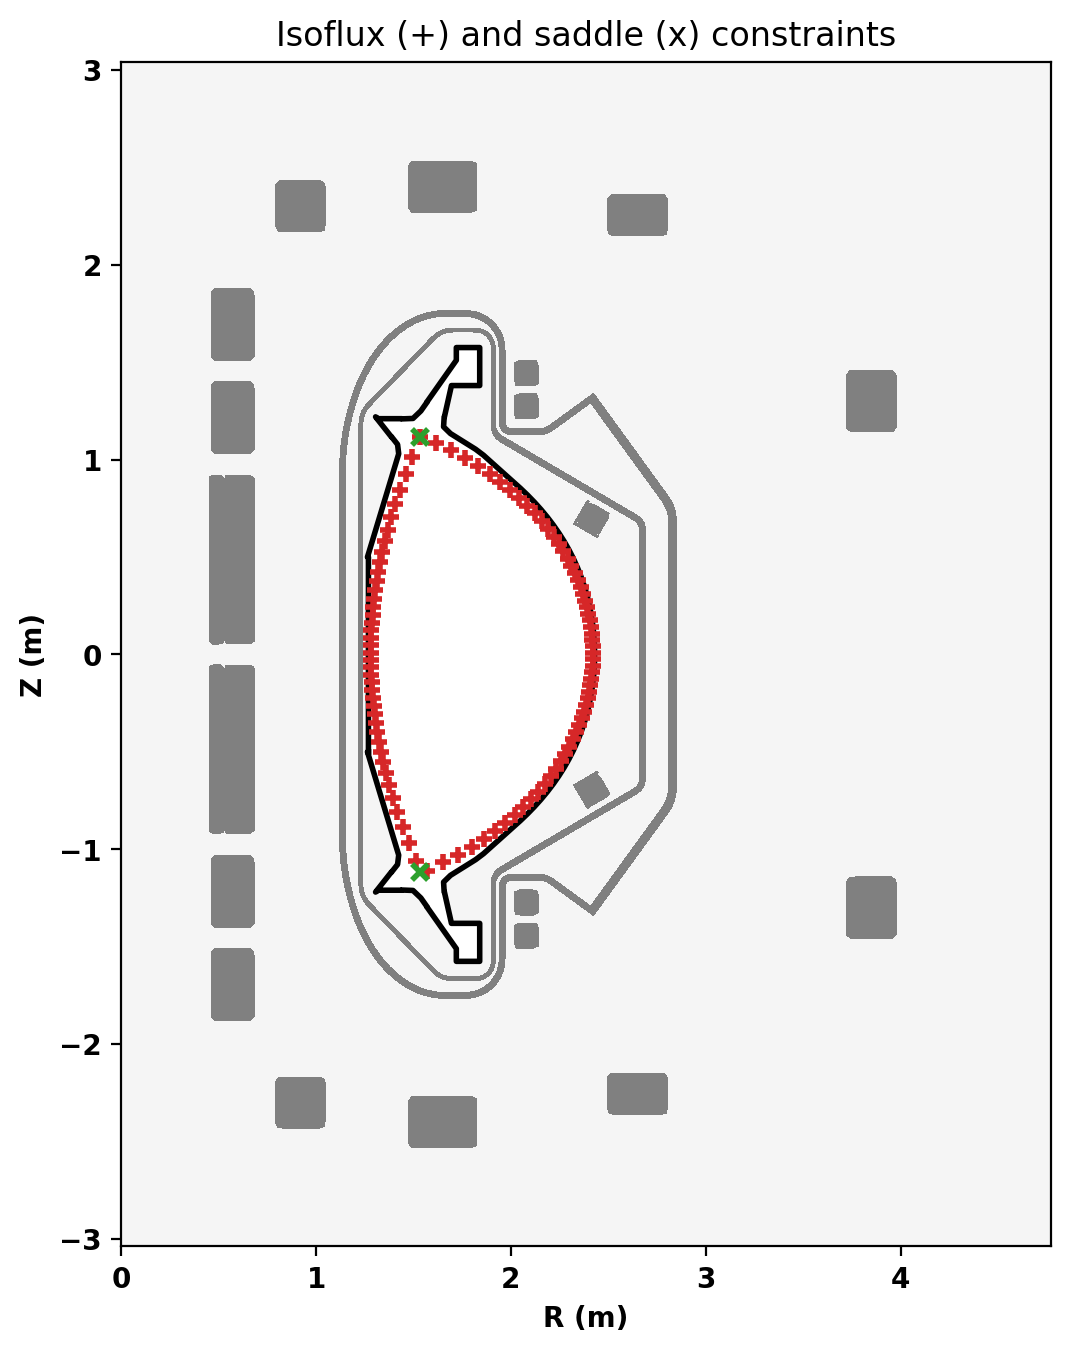

In [10]:
fig, ax = plt.subplots(1,1,figsize=(6,8))
mygs.plot_machine(fig,ax,coil_colormap=None)
mygs.plot_constraints(fig,ax)
ax.set_xlabel('R (m)')
ax.set_ylabel('Z (m)')
_ = ax.set_title('Isoflux (+) and saddle (x) constraints')

### Define coil regularization matrix

In [11]:
coil_names = list(mygs.coil_sets)
target_currents = {}
for name in coil_names:
    target_currents[name] = 0

# Set regularization weights
regularization_terms = []
for name, target_current in target_currents.items():
    if name.startswith('#'):
        continue
    if name.startswith('VS'):
        # In-vessel VS coils: keep them out of the shaping solution
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.E2))
    else:
        # CS, PF and DV coils
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=target_current,weight=1.E0))
# Set zero target current and small weight on virtual VSC to allow up-down adjustment
regularization_terms.append(mygs.coil_reg_term({'#VSC': 1.0},target=0.0,weight=1.E-2))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

### Define flux functions
Although TokaMaker has a "default" profile for the F\*F' and P' terms this should almost never be used and one should instead choose an appropriate flux function for their application. In this case we use the P' and F\*F' profiles directly from the gEQDSK we are working to reproduce.

In [12]:
ffprim = eqdsk['ffprim']
pprime = eqdsk['pprime']

psi_eqdsk = np.linspace(0.0,1.0,np.size(ffprim))
psi_sample = np.linspace(0.0,1.0,50)

ffp_prof = np.interp(psi_sample,psi_eqdsk,ffprim)
pp_prof = np.interp(psi_sample,psi_eqdsk,pprime)

mygs.set_profiles(ffp_prof={'type': 'linterp', 'y': ffp_prof, 'x': psi_sample},
                  pp_prof={'type': 'linterp', 'y': pp_prof, 'x': psi_sample})

### Compute equilibrium
We can now compute a free-boundary equilibrium using these constraints. Note that before running a calculation for the first time we must initialize the flux function $\psi$, which can be done using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.init_psi "init_psi()". This subroutine initializes the flux using the specified Ip_target from above, which is evenly distributed over the entire plasma region or only with a boundary defined using a center point (R,Z), minor radius (a), and elongation and triangularity. Coil currents are also initialized at this point using the constraints above and this uniform plasma current initialization.

Rather than hard-coding the initialization shape we measure it from the gEQDSK boundary contour, which gives $a = 0.57$ m, $\kappa = 1.96$ and $\delta = 0.56$ for the PRD.

\ref OpenFUSIONToolkit.TokaMaker.TokaMaker.solve "solve()" is then called to compute a self-consitent Grad-Shafranov equilibrium. If the result variable (`err_flag`) is zero then the solution has converged to the desired tolerance ($10^{-6}$ by default).

In [13]:
R0 = 1.85
Z0 = 0.0
a = 0.5*(isoflux_pts[:,0].max() - isoflux_pts[:,0].min())
kappa = (isoflux_pts[:,1].max() - isoflux_pts[:,1].min())/(2.0*a)
delta = (R0 - x_point_upper[0])/a

mygs.init_psi(R0, Z0, a, kappa, delta)
_ = mygs.solve()

Starting non-linear GS solver
     1  7.2949E-01  2.4769E-06  1.8559E-01  1.9085E+00  1.1440E-03  7.4755E+02
     2  1.6150E+00  1.5030E-06  7.3857E-02  1.9005E+00  1.2507E-03  5.8926E+02
     3  1.8070E+00  1.3443E-06  3.0918E-02  1.8960E+00  1.2681E-03  4.8239E+02
     4  1.8790E+00  1.2978E-06  1.4263E-02  1.8938E+00  1.2245E-03  4.2365E+02
     5  1.9117E+00  1.2802E-06  7.0019E-03  1.8927E+00  1.2003E-03  3.9425E+02
     6  1.9277E+00  1.2723E-06  3.5470E-03  1.8921E+00  1.1636E-03  3.8067E+02
     7  1.9358E+00  1.2685E-06  1.8241E-03  1.8918E+00  1.1278E-03  3.7512E+02
     8  1.9400E+00  1.2666E-06  9.4563E-04  1.8916E+00  1.0977E-03  3.7334E+02
     9  1.9422E+00  1.2656E-06  4.9243E-04  1.8916E+00  1.0744E-03  3.7318E+02
    10  1.9434E+00  1.2651E-06  2.5752E-04  1.8915E+00  1.0571E-03  3.7362E+02
    11  1.9440E+00  1.2649E-06  1.3489E-04  1.8915E+00  1.0447E-03  3.7420E+02
    12  1.9443E+00  1.2647E-06  7.1030E-05  1.8915E+00  1.0360E-03  3.7473E+02
    13  1.9444E+00  1.

### Plot equilibrium
Flux surfaces of the computed equilibrium can be plotted using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_psi "plot_psi()" method. The additional plotting methods \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_machine "plot_machine()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_constraints "plot_constraints()" are also used to show context and other information. Each method has a large number of optional arguments for formatting and other options.

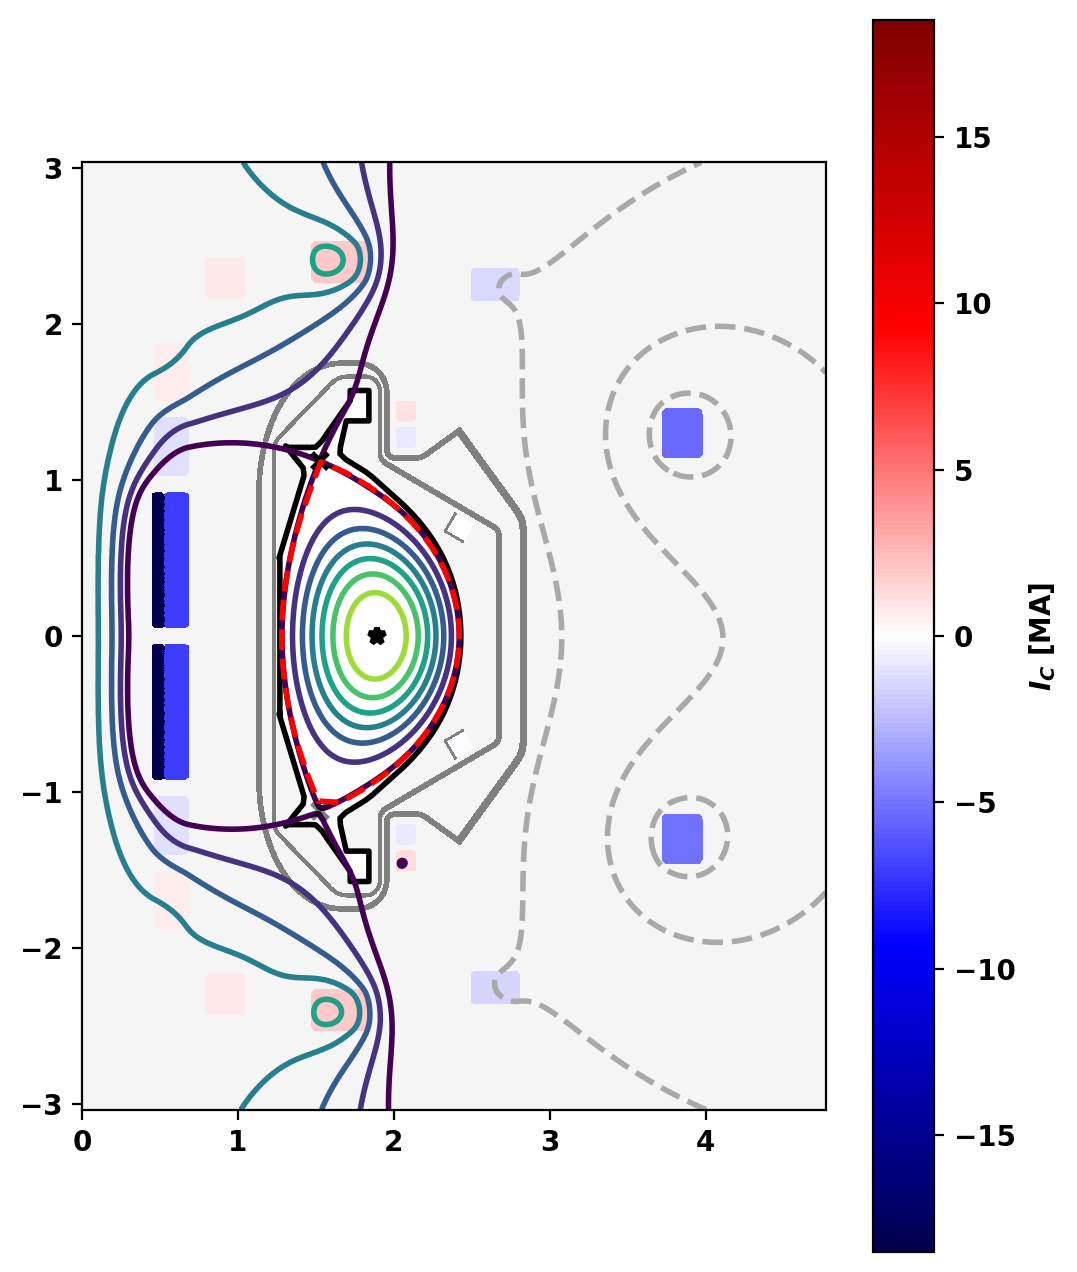

In [14]:
fig, ax = plt.subplots(1,1,figsize=(6,8))
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
mygs.plot_psi(fig,ax,vacuum_nlevels=4)
_ = ax.plot(eqdsk['rzout'][:,0][::2], eqdsk['rzout'][:,1][::2],'r--')

### Print equilibrium information and coil currents
Basic parameters can be displayed using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info()" method. For access to these quantities as variables instead the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_stats "get_stats()" can be used.

The final coil currents can also be retrieved using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_coil_currents "get_coil_currents()" method. Here, we print the deviation of the TokaMaker currents from the desired target currents set above. TokaMaker reports the current *per turn*; multiplying by the turn count from the device description gives the total A-turns in each coil.

**Note:** the turn counts in the open source device description are "toy data" — the coil *positions* are based on SPARC but the division into turns is not. The per-turn currents below should therefore be read as indicative rather than as SPARC engineering values. The device description also carries no coil current or field limits.

In [15]:
mygs.print_info()

currents, _ = mygs.get_coil_currents()
print()
print('  {0:10} {1:>12} {2:>12}'.format('Coil','I [kA]','Target [kA]'))
for key in currents:
    if key.startswith('#'):
        continue
    print('  {0:10} {1:12.2f} {2:12.2f}'.format(key+":",currents[key]/1.E3,target_currents[key]/1.E3))

Equilibrium Statistics:
  Topology                =   Diverted
  Toroidal Current [A]    =    8.7000E+06
  Current Centroid [m]    =    1.843  0.001
  Magnetic Axis [m]       =    1.891  0.001
  Elongation              =    1.969 (U:  1.992, L:  1.946)
  Triangularity           =    0.559 (U:  0.569, L:  0.550)
  Plasma Volume [m^3]     =   20.222
  q_0, q_95               =    0.950  3.168
  Plasma Pressure [Pa]    =   Axis:  2.5952E+06, Peak:  2.5952E+06
  Stored Energy [J]       =    1.8205E+07
  <Beta_pol> [%]          =   36.6018
  <Beta_tor> [%]          =    1.0218
  <Beta_n>   [%]          =    0.8110
  Diamagnetic flux [Wb]   =    2.3655E-01
  Toroidal flux [Wb]      =    2.3119E+01
  l_i                     =    1.2970

  Coil             I [kA]  Target [kA]
  CS1UI:           -66.14         0.00
  CS1UO:           -52.49         0.00
  CS1LI:           -65.75         0.00
  CS1LO:           -52.16         0.00
  CS2U:            -25.75         0.00
  CS2L:            -25.78 

### Retrieve profile information

Here, we use \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_profiles "get_profiles()" and \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_q "get_q()"to obtain the profiles of our equilibrium and compare them to the profiles of the target gEQDSK. Note the gEQDSK curves are plotted **without** the sign flip used in the ARC example, for the reason given above.

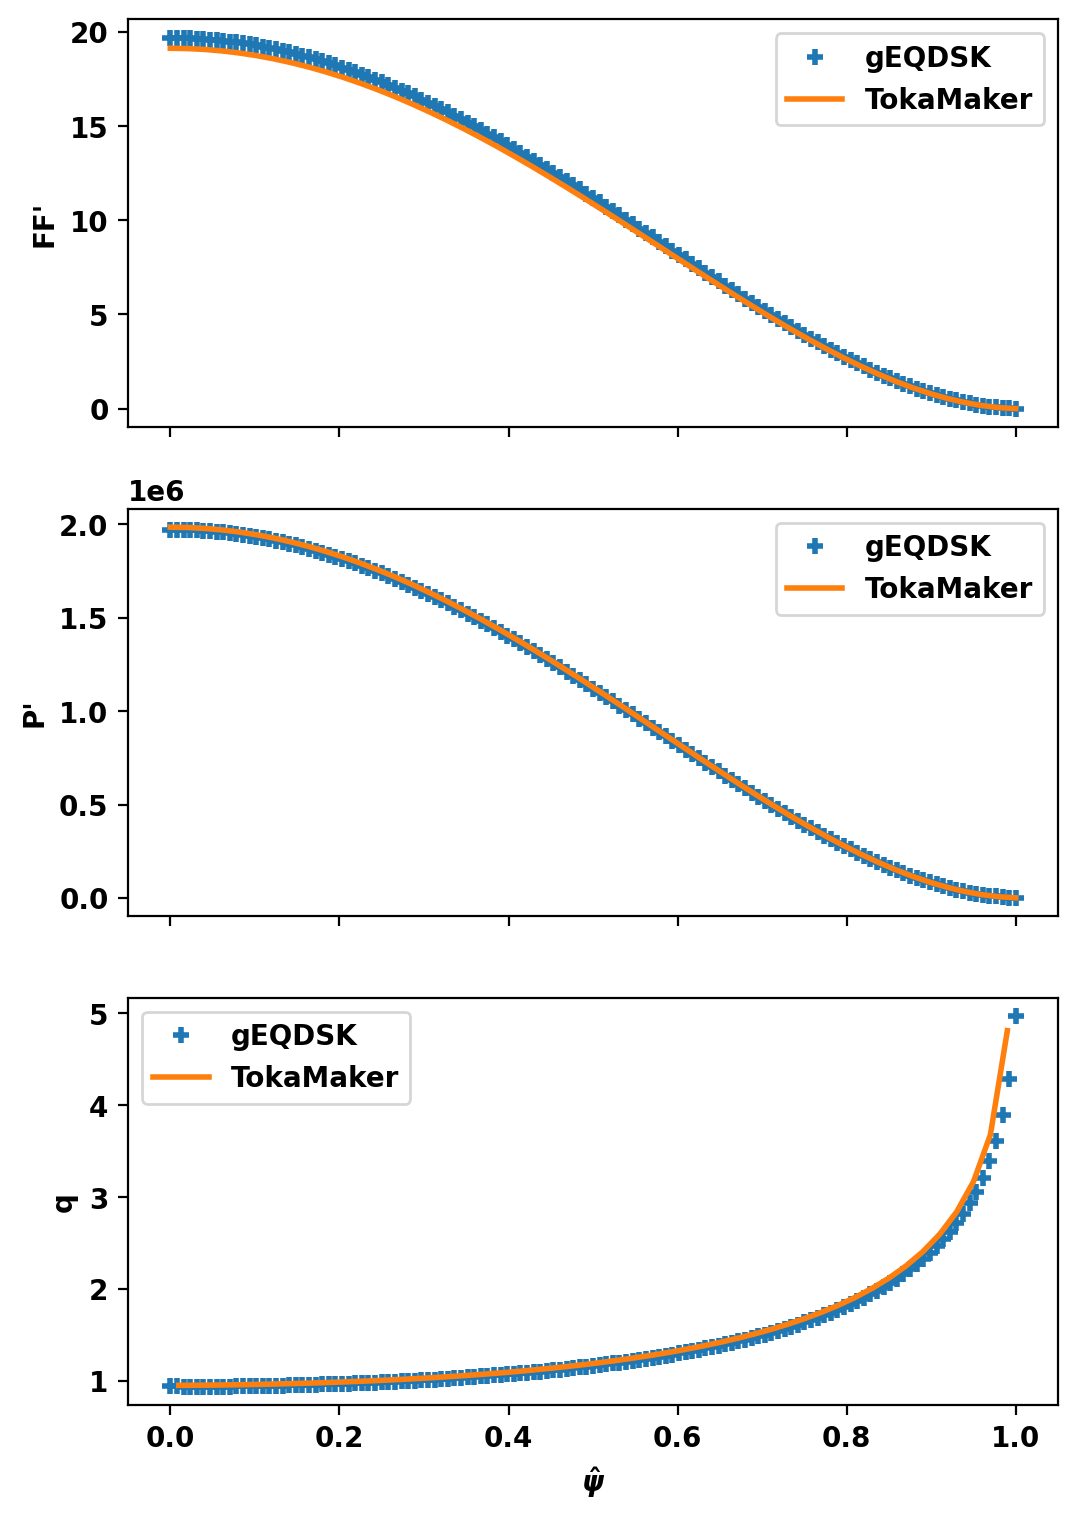

In [16]:
psi,f,fp,p,pp = mygs.get_profiles()
psi_q,qvals, _,_,_,_ = mygs.get_q(psi_pad=0.01)
fig, ax = plt.subplots(3,1,sharex=True,figsize=(6,9))
psi_eqdsk = np.linspace(0.0,1.0,eqdsk['nr'])
# Plot F*F'
ax[0].plot(psi_eqdsk,eqdsk['ffprim'],'+',label='gEQDSK')
ax[0].plot(psi,f*fp,label='TokaMaker')
ax[0].set_ylabel("FF'")
ax[0].legend()
# Plot P'
ax[1].plot(psi_eqdsk,eqdsk['pprime'],'+',label='gEQDSK')
ax[1].plot(psi,pp,label='TokaMaker')
ax[1].set_ylabel("P'")
ax[1].legend()
# Plot q
ax[2].plot(psi_eqdsk,eqdsk['qpsi'],'+',label='gEQDSK')
ax[2].plot(psi_q,abs(qvals),label='TokaMaker')
ax[2].set_ylabel("q")
ax[2].legend()
_ = ax[-1].set_xlabel(r"$\hat{\psi}$")

### Compare against the reference equilibrium (gEQDSK)

In [17]:
stats = mygs.get_stats()
psin_eqdsk = np.linspace(0.0,1.0,eqdsk['nr'])
q95_eqdsk = np.interp(0.95,psin_eqdsk,eqdsk['qpsi'])
lcfs = eqdsk['rzout']
a_eqdsk = 0.5*(lcfs[:,0].max() - lcfs[:,0].min())

print('  {0:22} {1:>12} {2:>12}'.format('Quantity','TokaMaker','gEQDSK'))
print('  {0:22} {1:12.2f} {2:12.2f}'.format('Ip [MA]', stats['Ip']/1.E6, abs(eqdsk['ip'])/1.E6))
print('  {0:22} {1:12.3f} {2:12.3f}'.format('R_axis [m]', mygs.o_point[0], eqdsk['raxis']))
print('  {0:22} {1:12.3f} {2:12.3f}'.format('kappa', stats['kappa'],
      (lcfs[:,1].max()-lcfs[:,1].min())/(2.0*a_eqdsk)))
print('  {0:22} {1:12.3f} {2:12.3f}'.format('q_0', abs(stats['q_0']), eqdsk['qpsi'][0]))
print('  {0:22} {1:12.3f} {2:12.3f}'.format('q_95', abs(stats['q_95']), q95_eqdsk))
print('  {0:22} {1:12.2f} {2:12.2f}'.format('p_axis [MPa]', stats['P_ax']/1.E6, eqdsk['pres'][0]/1.E6))
print()
print(f"  Topology: {'Diverted' if mygs.diverted else 'Limited'} (gEQDSK: double null)")

  Quantity                  TokaMaker       gEQDSK
  Ip [MA]                        8.70         8.70
  R_axis [m]                    1.891        1.890
  kappa                         1.969        1.955
  q_0                           0.950        0.939
  q_95                          3.168        3.008
  p_axis [MPa]                   2.60         2.60

  Topology: Diverted (gEQDSK: double null)
